# **Project 3 − A Galton Board on a Rocking Ship**
## Advanced Simulation and Machine Learning | TIF345
## Chalmers University of Technology | Fall 2025
---
### Linus Brink | [brinkl@chalmers.se](mailto:brinkl@chalmers.se) 
### Oscar Stommendal | [oscarsto@chalmers.se](mailto:oscarsto@chalmers.se)
---

## **Setup**

In [1]:

# Imports
import numpy as np
import matplotlib.pyplot as plt
import scipy
import emcee
from tqdm import tqdm

# Latex plotting settings
plt.rc('text', usetex = True)
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['font.family'] = 'palatino'
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath} \usepackage{amssymb} \usepackage{bm}'
font_size = 14
plt.rcParams['font.size'] = font_size
plt.rcParams['xtick.labelsize'] = font_size
plt.rcParams['ytick.labelsize'] = font_size
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.major.size'] = 5
plt.rcParams['ytick.major.size'] = 5
plt.rcParams['xtick.major.width'] = 1
plt.rcParams['ytick.major.width'] = 1
plt.rcParams['xtick.color'] = 'black'
plt.rcParams['ytick.color'] = 'black'

# General functions
def running_mean(x, factor):
    """
    Return the running mean of N element in a list.

    Args:
        x (ndarray): The list of elements,
        factor (float): The factor to multiply the length of the list by.
    
    Returns:
        ndarray: The running mean.
    """
    it, walker = x.shape
    N = int(factor * it)
    average = np.zeros((it - N+1,walker))
    #print(average.shape)
    for i in range(walker):
        cumsum = np.cumsum(np.insert(x[:,i], 0, 0))
        #print((cumsum[N:] - cumsum[:-N]).shape)
        average[:,i] = ((cumsum[N:] - cumsum[:-N]) / float(N))
    average = np.sum(average,axis=1) / walker

    return average

def trace_plotter(axs, sampler, iterations, sampler_idx=None, ndim=2, save=False):
    """
    Plot the traces of the MCMC chain.

    Args:
        axs (ndarray): The axes to plot on,
        sampler (emcee.EnsembleSampler): The sampler object,
        iterations (int): The number of iterations to plot,
        sampler_idx (str): The index of the sampler,
        ndim (int): The number of dimensions of the parameter space,
        save (bool): Whether to save the figure.
    """
    
    # If we have three parameters, plot the trace of sigma as well
    if ndim == 3:
        axs[0].plot([], [], 'k')
        axs[0].plot(running_mean(sampler.chain[:, :iterations, 0].T,factor=0.015),color='tab:red',alpha=1,linewidth = 2)#, label='Rolling average')
        axs[0].plot(sampler.chain[:, :iterations, 0].T, color='k', alpha=0.1)#, label='Traces $c_D$')
        axs[0].plot(running_mean(sampler.chain[:, :iterations, 0].T,factor=0.015),color='tab:red',alpha=1,linewidth = 2)#, label='Rolling average')
        axs[0].set_ylabel(r'$H_0$')
        axs[0].set_xticklabels([])
        axs[1].plot([], [], 'k')
        axs[1].plot(running_mean(sampler.chain[:, :iterations, 1].T,factor=0.015),color='tab:red',alpha=1,linewidth = 2)#, label='Rolling average')
        axs[1].plot(sampler.chain[:, :iterations, 1].T, color='k', alpha=0.1)#, label='Traces $c_E$')
        axs[1].plot(running_mean(sampler.chain[:, :iterations, 1].T,factor=0.015),color='tab:red',alpha=1,linewidth = 2)#, label='Rolling average')
        axs[1].set_ylabel(r'$q_0$')
        axs[1].set_xticklabels([])
        axs[2].plot([], [], 'k')
        axs[2].plot(running_mean(sampler.chain[:, :iterations, 2].T,factor=0.015),color='tab:red',alpha=1,linewidth = 2)
        axs[2].plot(sampler.chain[:, :iterations, 2].T, color='k', alpha=0.3)
        axs[2].plot(running_mean(sampler.chain[:, :iterations, 2].T,factor=0.015),color='tab:red',alpha=1,linewidth = 2)
        axs[2].set_ylabel(r'$\sigma_{\mathrm{sys}}^2$')
        axs[2].set_xlabel('Sampler Iteration')
        axs[2].legend(['Traces','Rolling averages'], loc = 'lower center', bbox_to_anchor=(0.47, -0.55), ncol=2)
    else:
        # If we have 3 or more parameters, plot all of them
        for i, ax in enumerate(axs):
            ax.plot([], [], 'k')
            ax.plot(running_mean(sampler.chain[:, :iterations, i].T,factor=0.015),color='tab:red',alpha=1,linewidth = 2)#, label='Rolling average')
            ax.plot(sampler.chain[:, :iterations, i].T, color='k', alpha=0.1)#, label='Traces $c_D$')
            ax.plot(running_mean(sampler.chain[:, :iterations, i].T,factor=0.015),color='tab:red',alpha=1,linewidth = 2)#, label='Rolling average')
            ax.set_ylabel(r'$J_{'+str(i)+'}$')
            # if i != len(axs) - 2:
            #     ax.set_xticklabels([])
            # else:
            #     ax.set_xlabel('Sampler Iteration')
        axs[-1].legend(['Traces','Rolling averages'], loc = 'lower center', bbox_to_anchor=(0.47, -0.55), ncol=2)

    if save:
        axs[0].figure.savefig('figs/post_samples'+sampler_idx+'.pdf', bbox_inches='tight')


## **Read data and parameter definitions**

In [12]:

data_file = 'data/board_data.npy'
board_data = np.load(data_file)

n_trials = board_data.shape[0]
n_cols = board_data.shape[1]
n_rows = board_data.shape[1] - 1
n_beads = np.sum(board_data[0])

print(f'Number of experiments: {n_trials}')
print(f'Galton board with {n_rows} rows and {n_cols} columns, total number of beads: {n_beads:.0f}')


Number of experiments: 10000
Galton board with 31 rows and 32 columns, total number of beads: 1000


## **General Dalton Simulator**

In [31]:

def dalton_probability_model(M, alpha, s):
    '''
    Model for the Dalton board.

    Args:
        M (float): Previous bounce parameter, 0 at entrance, -0.5 if bounced left last time, +0.5 if bounced right last time,
        alpha (float): Bias parameter,
        s (float): Rocking parameter describing tilt of the rocking ship.

    Returns:
        prob_right (float): Probability of bouncing right,
        prob_left (float): Probability of bouncing left.
    '''

    prob_right = 0.5 + (alpha * M + s)
    prob_left = 0.5 - (alpha * M + s)

    return prob_right, prob_left

def dalton_simulator(n_rows, n_cols, n_beads, alpha, s):
    '''
    Simulate the Dalton board on a rocking ship.

    Args:
        n_rows (int): Number of rows,
        n_cols (int): Number of columns,
        n_beads (int): Number of beads to simulate,
        alpha (float): Bias parameter,
        s (float): Rocking parameter describing tilt of the rocking ship.

    Returns:
        trench_positions (ndarray): The number of beads in each trench.
    '''

    # Initialize the board, even positions are trenches and odd positions are pegs
    positions = np.zeros(n_cols + n_rows)

    for _ in tqdm(range(int(n_beads)), desc='Simulating Dalton board'):
        position = positions.shape[0] // 2 # Start in the middle
        M = 0 # Initial bounce parameter

        for _ in range(n_rows):
            prob_right, prob_left = dalton_probability_model(M, alpha, s)
            move = np.random.choice(['R', 'L'], p=[prob_right, prob_left])

            if move == 'R':
                position += 1
                M = 0.5
            else:
                position -= 1
                M = -0.5

        positions[position] += 1
    trench_positions = positions[[2 * i for i in range(len(positions) // 2)]]

    return trench_positions


In [32]:

trench_positions = dalton_simulator(n_rows, n_cols, n_beads, alpha=0.1, s=0.0)


Simulating Dalton board: 100%|██████████| 1000/1000 [00:00<00:00, 1038.83it/s]


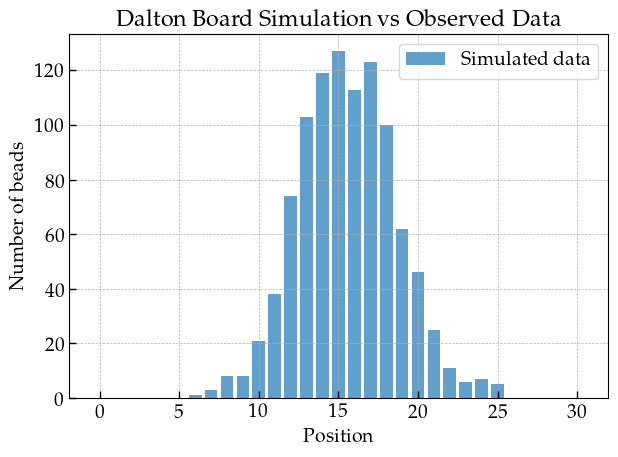

In [34]:

plt.bar(np.arange(len(trench_positions)), trench_positions, alpha=0.7, label='Simulated data')
plt.xlabel('Position')
plt.ylabel('Number of beads')
plt.legend()
plt.title('Dalton Board Simulation vs Observed Data')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()


---